In [266]:
import numpy as np 
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt 


### Cleaning Columns for the Salary prediction

### 1. Salary column


In [267]:
df = pd.read_csv('tech_job_market_2019_2026.csv')

In [268]:
df.head()

,job_id,company_name,company_type,sector,company_size_employees,hq_country,job_role,seniority_level,years_experience_min,years_experience_max,...,application_deadline,date_position_filled,position_status,number_of_applicants,number_of_interview_rounds,offers_extended,offers_accepted,salary_min_usd,salary_max_usd,layoff_within_12_months_flag
0,JOB041385,CobaltWealth,MNC,HealthTech,146085,Germany,SOC Analyst,Mid,3,5,...,2023-11-12 00:00:00,2023-11-20,Filled,98.0,4.0,5.0,5.0,-1,-1,N
1,JOB018462,DriftLearn,Mid-size,Cloud/Infra,5882,USA,Mobile Engineer (iOS),Mid,1,4,...,2025-06-29 00:00:00,NaN,Open,134.0,2.0,1.0,0.0,NaN,NaN,No
2,JOB110011,AnchorBuzz Labs,MNC,HealthTech,186507,USA,QA Engineer,Lead,7,15,...,2026-01-24 00:00:00,2026-02-08,Filled,36.0,4.0,1.0,1.0,238800.0,274700.0,0
3,JOB073462,KiteSphere,Unicorn,HealthTech,10930,Brazil,Research Scientist,Entry,1,4,...,2020-12-09 00:00:00,2020-12-21,Filled,300.0,1.0,6.0,5.0,96300.0,104000.0,Yes
4,JOB051683,AetherNode Co,MNC,Social/AdTech,42510,USA,Product Manager,Senior,6,9,...,2025-07-19 00:00:00,2025-09-15,Filled,43.0,3.0,1.0,1.0,"$186,800",245400.0,1


In [269]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115000 entries, 0 to 114999
Data columns (total 28 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   job_id                        115000 non-null  object 
 1   company_name                  115000 non-null  object 
 2   company_type                  115000 non-null  object 
 3   sector                        115000 non-null  object 
 4   company_size_employees        115000 non-null  int64  
 5   hq_country                    115000 non-null  object 
 6   job_role                      115000 non-null  object 
 7   seniority_level               115000 non-null  object 
 8   years_experience_min          115000 non-null  int64  
 9   years_experience_max          115000 non-null  int64  
 10  required_tech_stack           115000 non-null  object 
 11  primary_programming_language  92525 non-null   object 
 12  work_mode                     115000 non-nul

In [270]:
df['salary_min_usd'].isnull().sum()

np.int64(3318)

In [271]:
df['salary_max_usd'].isnull().sum()

np.int64(3318)

In [272]:
df['salary_min_usd'] = df['salary_min_usd'].str.replace(r'[^0-9.-]',"",regex = True)

In [273]:
df['salary_min_usd'] = pd.to_numeric(df['salary_min_usd'], errors='coerce')


In [274]:
df['salary_min_usd'] = df['salary_min_usd'].fillna(df['salary_min_usd'].mean())

In [275]:
df['salary_min_usd'].astype(int)

0             -1
1         114677
2         238800
3          96300
4         186800
           ...  
114995    215300
114996     87500
114997    126000
114998    156000
114999    120400
Name: salary_min_usd, Length: 115000, dtype: int64

In [276]:
df['salary_max_usd'] = df['salary_max_usd'].str.replace(r'[^0-9.-]',"",regex = True)

In [277]:
df['salary_max_usd'] = pd.to_numeric(df['salary_max_usd'],errors='coerce')

In [278]:
df['salary_max_usd'] = df['salary_max_usd'].fillna(df['salary_max_usd'].mean())

In [279]:
df['salary_max_usd'].astype(int)

0             -1
1         141712
2         274700
3         104000
4         245400
           ...  
114995    254300
114996    113500
114997    156400
114998    174100
114999    147000
Name: salary_max_usd, Length: 115000, dtype: int64

In [280]:
df.loc[df['salary_min_usd'] <= 0, 'salary_min_usd'] = np.nan
df.loc[df['salary_max_usd'] <= 0, 'salary_max_usd'] = np.nan

In [281]:
df['Average_Salary'] = np.where(
    df['salary_min_usd'] > df['salary_max_usd'],
    None,
    (df['salary_max_usd'] + df['salary_min_usd']) / 2
)

In [282]:
df['Average_Salary']

0                   NaN
1         128194.873626
2              256750.0
3              100150.0
4              216100.0
              ...      
114995         234800.0
114996         100500.0
114997         141200.0
114998         165050.0
114999         133700.0
Name: Average_Salary, Length: 115000, dtype: object

In [283]:
df['Average_Salary'].isna().sum()

np.int64(1189)

In [284]:
df['Average_Salary'] = df['Average_Salary'].fillna(df['Average_Salary'].mean())


C:\Users\anshu\AppData\Local\Temp\ipykernel_7904\2889260269.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Average_Salary'] = df['Average_Salary'].fillna(df['Average_Salary'].mean())


In [285]:
df['Average_Salary'].astype(int)

0         129035
1         128194
2         256750
3         100150
4         216100
           ...  
114995    234800
114996    100500
114997    141200
114998    165050
114999    133700
Name: Average_Salary, Length: 115000, dtype: int64

In [286]:
df['Average_experience'] = (df['years_experience_min']+df['years_experience_max'])/2

In [287]:
df['Average_experience']

0          4.0
1          2.5
2         11.0
3          2.5
4          7.5
          ... 
114995    11.5
114996     7.0
114997     4.0
114998     6.5
114999     4.5
Name: Average_experience, Length: 115000, dtype: float64

In [288]:
df['number_of_interview_rounds']

0         4.0
1         2.0
2         4.0
3         1.0
4         3.0
         ... 
114995    6.0
114996    4.0
114997    3.0
114998    4.0
114999    4.0
Name: number_of_interview_rounds, Length: 115000, dtype: float64

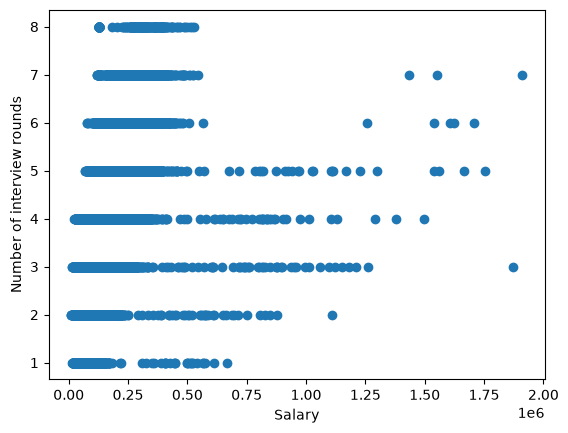

In [289]:
plt.scatter(df['Average_Salary'],df['number_of_interview_rounds'])
plt.xlabel('Salary')
plt.ylabel('Number of interview rounds')
plt.show()

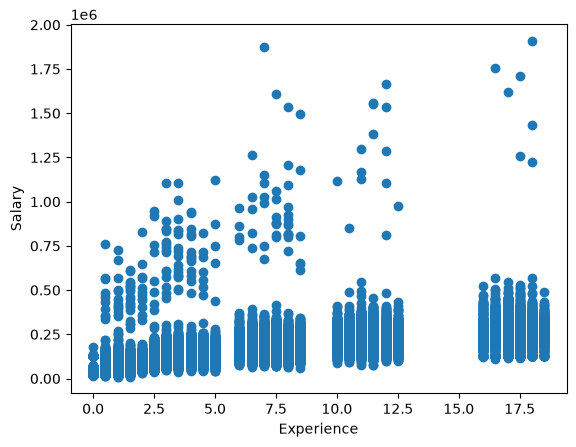

In [290]:
plt.scatter(y=df['Average_Salary'],x=df['Average_experience'])
plt.xlabel('Experience')
plt.ylabel('Salary')
plt.show()